#**Installation, Mounting, and Dataset Loading**

In [ ]:
!pip install pandas numpy matplotlib scikit-learn seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Anh Ha
# Open zip files for reading
import pandas as pd
import os

file_path = '/content/drive/My Drive/airbnb_cleaned_data.csv'

if file_path.endswith('.gz'):
        # This block runs if the file name ends with .gz
        df = pd.read_csv(file_path, compression='gzip')

elif file_path.endswith('.csv'):
        # This block runs if it ends with .csv
        df = pd.read_csv(file_path)
# pd.set_option('display.max_columns', None)
# Check if it worked
df.head()

,id,price,host_id,host_since,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_identity_verified,host_experience_years,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,unique_reviewers_count,reviewer_diversity,rating_consistency
0,3781,125.0,4804.0,2008-12-03,1.00,0.19,1.0,3.0,0.0,16.945205,...,4.96,5.00,4.96,5.00,4.96,4.85,4.88,25.0,0.961538,0.945453
1,5506,129.0,8229.0,2009-02-19,1.00,1.00,1.0,12.0,1.0,16.731507,...,4.82,4.89,4.91,4.95,4.90,4.58,4.77,138.0,1.000000,0.887980
2,6695,168.0,8229.0,2009-02-19,1.00,1.00,1.0,12.0,1.0,16.731507,...,4.81,4.83,4.86,4.90,4.94,4.54,4.72,141.0,1.000000,0.881610
3,8789,140.0,26988.0,2009-07-22,1.00,0.37,1.0,8.0,1.0,16.312329,...,4.69,4.69,4.55,4.93,4.97,4.97,4.59,28.0,0.965517,0.845874
4,10811,166.0,38997.0,2009-09-16,0.94,0.59,0.0,21.0,1.0,16.158904,...,4.33,4.44,4.67,4.56,4.00,5.00,4.67,9.0,1.000000,0.761313


#**Data Splitting and Scaling**

In [ ]:
# Anh Ha
# Split data into 8:1:1 for training, validation and test sets
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler

# Load file
file_name = '/content/drive/My Drive/airbnb_cleaned_data.csv'
df = pd.read_csv(file_name)

#print(f"Loaded data with {df.shape[0]} rows and {df.shape[1]} columns.")
#print(df.head()) # Print first 5 rows to check

# --- Separate Features (X) and Target (y) ---
feature_columns = [

    # Core Property Features
    'accommodates',
    'bathrooms',
    'room_type_encoded',
    'instant_bookable',
    'minimum_nights',
    'maximum_nights',
    'availability_30',

    # Location
    'distance_to_center',

    # Controllable Features

    # Host Performance
    #'host_response_rate',
    'host_is_superhost',
    'host_acceptance_rate', # the rate that host accecpt order

    # amenities
    'has_wifi',
    'has_kitchen',
    'has_air_conditioning',
    'has_heating',
    'has_washer',
    'has_dryer',
    'has_tv',
    'has_parking',
    'has_gym',
    'has_pet_friendly',

    #reviews
    #'neighborhood_density',
    'room_type_density',
    'number_of_reviews',
    'review_scores_rating',
    'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value'

]
target_column = 'price'

y = np.log1p(df[target_column])
X = df[feature_columns]


# First Split (80% train, 20% temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=X['room_type_encoded']  # STRATIFY on the 'room_type' column.
)

# Second Split (half of temp to val, half to test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Uncomment to check Results
# print("\nSplitting complete.")
# print(f"Training set:   {X_train.shape[0]} rows")
# print(f"Validation set: {X_val.shape[0]} rows")
# print(f"Test set:       {X_test.shape[0]} rows")

# print("\n--- Check: 'room_type_encoded' distribution ---")
# # Should be nearly identical
# print("\nOriginal:\n", X['room_type_encoded'].value_counts(normalize=True))
# print("\nTraining:\n", X_train['room_type_encoded'].value_counts(normalize=True))
# print("\nValidation:\n", X_val['room_type_encoded'].value_counts(normalize=True))
# print("\nTest:\n", X_test['room_type_encoded'].value_counts(normalize=True))

# Scaling data for features that are on different scales
continuous_features = [

    'accommodates',
    'bathrooms',
    'distance_to_center',
    #'host_response_rate',
    'host_acceptance_rate',
    'minimum_nights',
    'maximum_nights',
    'availability_30',
    'number_of_reviews',
    'review_scores_rating',
    'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value'
]

# Initialize
scaler = StandardScaler()

# Fit on training data
scaler.fit(X_train[continuous_features])

# Store Results
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

#Transform
X_train_scaled[continuous_features] = scaler.transform(X_train[continuous_features])
X_val_scaled[continuous_features] = scaler.transform(X_val[continuous_features])
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])

# Results
print("--- Original X_train ---")
print(X_train[continuous_features].head())
print("\n")

print("--- Scaled X_train (features are now centered around 0) ---")
print(X_train_scaled[continuous_features].head())

--- Original X_train ---
      accommodates  bathrooms  distance_to_center  host_acceptance_rate  \
1740           2.0        1.0            3.126843                  0.96   
1823           4.0        1.5            5.938808                  0.95   
2889           1.0        1.0            0.365836                  0.93   
369            4.0        1.0            3.123361                  0.99   
1841           6.0        2.5            1.090380                  1.00   

      minimum_nights  maximum_nights  availability_30  number_of_reviews  \
1740            45.0           270.0              0.0                7.0   
1823             3.0           365.0              4.0               45.0   
2889            29.0           365.0             11.0                0.0   
369              3.0           730.0              5.0              218.0   
1841             3.0           365.0             19.0               23.0   

      review_scores_rating  review_scores_accuracy  review_scores_c

#**Correlation Exploration and Modeling**
####Looking into the most correlated features compared to price

In [ ]:
# Christina Tran

df2 = df.drop(['host_since'], axis=1)
df2.head()
corr_matrix = round(df2.corr(),5) # round 5 decimal places
#-- should change 'host_since' to 'host_experience' for years of experience (float) or find another way to map the dates to float values
#-- for now, just dropped 'host_since' feature to make df2 -- does not change the original scaled df.
corr_matrix # nxn table for n features w correlations

#see correlations for one feature
corrs = corr_matrix['price']
corrs

#sort correaltions
corrs_sorted = corrs.sort_values(ascending=False)
print("Correlations of all features to price, sorted in descending order:")
print(corrs_sorted)


Correlations of all features to price, sorted in descending order:
price                    1.00000
accommodates             0.57799
bathrooms                0.46287
bedrooms                 0.46018
instant_bookable         0.22217
                          ...   
distance_to_airport     -0.22068
distance_to_mit         -0.23773
property_type_encoded   -0.27182
distance_to_center      -0.27880
room_type_encoded       -0.41547
Name: price, Length: 61, dtype: float64


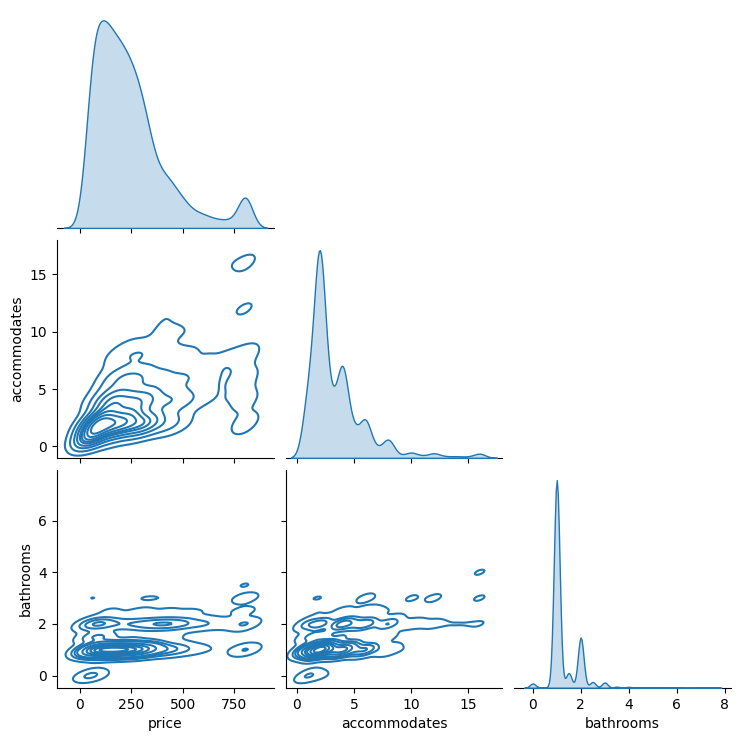

In [ ]:
# Christina Tran

import seaborn as sns
#plot price label and its top 2 highest correlates
df_corrs = df2[['price', 'accommodates', 'bathrooms']]
df_corrs

#make seaborn pairplot, kernel density estimater
sns.pairplot(data=df_corrs, kind='kde', corner=True)

#**Random Forest Model**


In [ ]:
# Anh Ha
# Random Forest Model
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from scipy.stats import randint
import numpy as np
import pandas as pd

# n_estimators= build 100 different trees.
# random_state=42 ensures same result every time.
# n_jobs=-1 uses all computer's cores to speed it up.

rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1,
                                    max_depth= 10, min_samples_split = 10,
                                 min_samples_leaf = 5, max_features = 'sqrt' )

# 3-fold cross validation for Random Forest
print("\n--- Random Forest 3-fold Cross-Validation ---")
kf = KFold(n_splits=3, shuffle=True, random_state=42)
rf_cv_r2 = cross_val_score(rf_model, X_train_scaled, y_train, cv=kf, scoring='r2')
rf_cv_mae = cross_val_score(rf_model, X_train_scaled, y_train, cv=kf, scoring='neg_mean_absolute_error')
rf_cv_mae = -rf_cv_mae

print(f"3-fold cross validation R²: {rf_cv_r2.mean():.4f},(+-: {rf_cv_r2.std():.4f})")
print(f"3-fold cross validation MAE: {rf_cv_mae.mean():.4f}, (+-: {rf_cv_mae.std():.4f})\n")


print("Training the Random Forest model... (this may take a moment)")
rf_model.fit(X_train_scaled, y_train)
print("Training complete.")

print("\n--- Random Forest Model Evaluation ---")

print("\n--- Training Set ---")
train_predictions_rf = rf_model.predict(X_train_scaled)
r2_train_rf = r2_score(y_train, train_predictions_rf)
mae_train_rf = mean_absolute_error(y_train, train_predictions_rf)

print(f"Training R-squared (R²): {r2_train_rf:.4f}")
print(f"Training Mean Absolute Error (MAE): {mae_train_rf:.4f}")

# --- 2. Validation Set Metrics ---
# (Used for tuning the model and checking for overfitting)
print("\n--- Validation Set ---")
val_predictions_rf = rf_model.predict(X_val_scaled)
r2_validation_rf = r2_score(y_val, val_predictions_rf)
mae_validation_rf = mean_absolute_error(y_val, val_predictions_rf)

print(f"Validation R-squared (R²): {r2_validation_rf:.4f}")
print(f"Validation Mean Absolute Error (MAE): {mae_validation_rf:.4f}")

# --- 3. Test Set Metrics ---
# (The final, "real" score on unseen data)
print("\n--- Test Set ---")
test_predictions_rf = rf_model.predict(X_test_scaled)
r2_test_rf = r2_score(y_test, test_predictions_rf)
mae_test_rf = mean_absolute_error(y_test, test_predictions_rf)

print(f"Test R-squared (R²): {r2_test_rf:.4f}")
print(f"Test Mean Absolute Error (MAE): {mae_test_rf:.4f}")

print("\nInterpretation:")
print(f"This model explains {r2_validation_rf*100:.2f}% of the variance in review scores.")
print(f"On average, the model's prediction for a review score is off by {mae_validation_rf:.4f} points.")



--- Random Forest 3-fold Cross-Validation ---
3-fold cross validation R²: 0.7755,(+-: 0.0101)
3-fold cross validation MAE: 0.2552, (+-: 0.0046)

Training the Random Forest model... (this may take a moment)
Training complete.

--- Random Forest Model Evaluation ---

--- Training Set ---
Training R-squared (R²): 0.8561
Training Mean Absolute Error (MAE): 0.2036

--- Validation Set ---
Validation R-squared (R²): 0.8364
Validation Mean Absolute Error (MAE): 0.2364

--- Test Set ---
Test R-squared (R²): 0.7786
Test Mean Absolute Error (MAE): 0.2545

Interpretation:
This model explains 83.64% of the variance in review scores.
On average, the model's prediction for a review score is off by 0.2364 points.


In [ ]:
# Get the importance scores from the trained model
importances = rf_model.feature_importances_

# Create a DataFrame to see them clearly
feature_importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

print("Top 10 most important features for predicting review scores:")
print(feature_importance_df.head(10))

Top 10 most important features for predicting review scores:
                   feature  importance
2        room_type_encoded    0.254715
0             accommodates    0.203615
7       distance_to_center    0.105521
1                bathrooms    0.086141
20       room_type_density    0.070457
4           minimum_nights    0.057361
3         instant_bookable    0.029421
9     host_acceptance_rate    0.028115
6          availability_30    0.026862
27  review_scores_location    0.023495


#**Linear Regression Model**

In [ ]:
# Anh Ha
# Linear Regression Model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, r2_score


lr_model = LinearRegression()

# 3-fold cross validation for linear regression
print("\n--- Linear Regression 3-fold Cross-Validation ---")
kf = KFold(n_splits=3, shuffle=True, random_state=42)
lr_cv_r2 = cross_val_score(lr_model, X_train_scaled, y_train, cv=kf, scoring='r2')
lr_cv_mae = cross_val_score(lr_model, X_train_scaled, y_train, cv=kf, scoring='neg_mean_absolute_error')
lr_cv_mae = -lr_cv_mae

print(f"3-fold cross validation R²: {lr_cv_r2.mean():.4f},(+-: {lr_cv_r2.std():.4f})")
print(f"3-fold cross validation MAE: {lr_cv_mae.mean():.4f}, (+-: {lr_cv_mae.std():.4f})\n")

print("Training the model...")
lr_model.fit(X_train_scaled, y_train)
print("Training complete.")

print("\n--- Linear Regression Model Evaluation ---")

# Predictions for the training test

print("\n--- Training Set ---")
# Get the R-squared (R²) score
# R² tells you how much of the variation in review scores
r2_train = lr_model.score(X_train_scaled,y_train)
# Get the model's predictions for the training set
train_predictions = lr_model.predict(X_train_scaled)
# Calculate Mean Absolute Error (MAE)
mae_train = mean_absolute_error(y_train, train_predictions)

print(f"Training R-squared (R²): {r2_train:.4f}")
print(f"Training Mean Absolute Error (MAE): {mae_train:.4f}")


# Predictions for the test set
print("\n--- Testing Set ---")
r2_test = lr_model.score(X_test_scaled, y_test)
test_predictions = lr_model.predict(X_test_scaled)
mae_test = mean_absolute_error(y_test, test_predictions)

print(f"Test R-squared (R²): {r2_test:.4f}")
print(f"Test Mean Absolute Error (MAE): {mae_test:.4f}")

# Predictions for the training set
print("\n--- Validation Set ---")
r2_validation = lr_model.score(X_val_scaled, y_val)
val_predictions = lr_model.predict(X_val_scaled)
mae_validation = mean_absolute_error(y_val, val_predictions)

# Results
print(f"Validation R-squared (R²): {r2_validation:.4f}")
print(f"Validation Mean Absolute Error (MAE): {mae_validation:.4f}")

print("\nInterpretation:")
print(f"This model explains {r2_validation*100:.2f}% of the variance in review scores.")
print(f"On average, the model's prediction for a review score is off by {mae_validation:.4f} points.")




--- Linear Regression 3-fold Cross-Validation ---
3-fold cross validation R²: 0.6505,(+-: 0.0131)
3-fold cross validation MAE: 0.3257, (+-: 0.0036)

Training the model...
Training complete.

--- Linear Regression Model Evaluation ---

--- Training Set ---
Training R-squared (R²): 0.6610
Training Mean Absolute Error (MAE): 0.3212

--- Testing Set ---
Test R-squared (R²): 0.6725
Test Mean Absolute Error (MAE): 0.3219

--- Training Set ---
Validation R-squared (R²): 0.7144
Validation Mean Absolute Error (MAE): 0.3117

Interpretation:
This model explains 71.44% of the variance in review scores.
On average, the model's prediction for a review score is off by 0.3117 points.


In [ ]:
# Price Optimizing Simulation for User Input
'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

user_data = {
    'price': 0,  # Placeholder
    'accommodates': 2,
    'bathrooms': 1,
    'room_type_encoded': 0, # entire apt
    'distance_to_center': 2.5,
    'instant_bookable': 1,
    'has_pet_friendly': 0,
    'minimum_nights': 1,
    'has_wifi': 1,
    'has_kitchen': 1,
    'has_air_conditioning': 1,
    'has_heating': 1,
    'has_washer': 1,
    'has_dryer': 0,
    'has_tv': 1,
    'has_parking': 1,
    'has_gym': 0,
    'maximum_nights': 365,
    'availability_30': 25,
    'host_response_rate': 1.0,
    'host_is_superhost': 0,
    'host_acceptance_rate': 1.0,
}

# creates price range to test
test_range = np.linspace(100,1000,1000)

predictions = []
print('Running predictions')

for price in test_range:

  current_listing = pd.DataFrame(user_data, index=[0])
  current_listing['price'] = price

  current_listing = current_listing[feature_columns]

  current_listing_scaled = current_listing.copy()
  current_listing_scaled[continuous_features] = scaler.transform(current_listing[continuous_features])
  prediction = rf_model.predict(current_listing_scaled)
  predictions.append((price, prediction[0]))

print("Simulation complete.")
results_df = pd.DataFrame(predictions, columns=['Price', 'Predicted_Reviews_Per_Month'])
results_df = results_df.sort_values(by='Predicted_Reviews_Per_Month', ascending=False)
print('Top 5 prices:')
print(results_df.head())
'''

'\nimport numpy as np\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\nuser_data = {\n    \'price\': 0,  # Placeholder\n    \'accommodates\': 2,\n    \'bathrooms\': 1,\n    \'room_type_encoded\': 0, # entire apt\n    \'distance_to_center\': 2.5,\n    \'instant_bookable\': 1,\n    \'has_pet_friendly\': 0,\n    \'minimum_nights\': 1,\n    \'has_wifi\': 1,\n    \'has_kitchen\': 1,\n    \'has_air_conditioning\': 1,\n    \'has_heating\': 1,\n    \'has_washer\': 1,\n    \'has_dryer\': 0,\n    \'has_tv\': 1,\n    \'has_parking\': 1,\n    \'has_gym\': 0,\n    \'maximum_nights\': 365,\n    \'availability_30\': 25,\n    \'host_response_rate\': 1.0,\n    \'host_is_superhost\': 0,\n    \'host_acceptance_rate\': 1.0,\n}\n\n# creates price range to test\ntest_range = np.linspace(100,1000,1000)\n\npredictions = []\nprint(\'Running predictions\')\n\nfor price in test_range:\n\n  current_listing = pd.DataFrame(user_data, index=[0])\n  current_listing[\'price\'] = price\n\n  current_listing = cu